# Machine Learning Model Implementations

This notebook demonstrates the implementation and visualization of various machine learning models, including Perceptron for linear classification and Multi-Layer Perceptron (MLP) for more complex tasks. It covers data loading, model training, and evaluation for different datasets.

### Perceptron on Iris Dataset (Setosa vs. Versicolor)

This section demonstrates the use of a Perceptron model to classify two classes from the Iris dataset: Setosa and Versicolor. The Perceptron is a fundamental algorithm for supervised learning of binary classifiers. We will visualize its decision boundary based on two features: Sepal Length and Sepal Width.

<ipython-input-1-700671526eec>:38: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='x', label='Test', edgecolor='k', cmap=plt.cm.Paired)


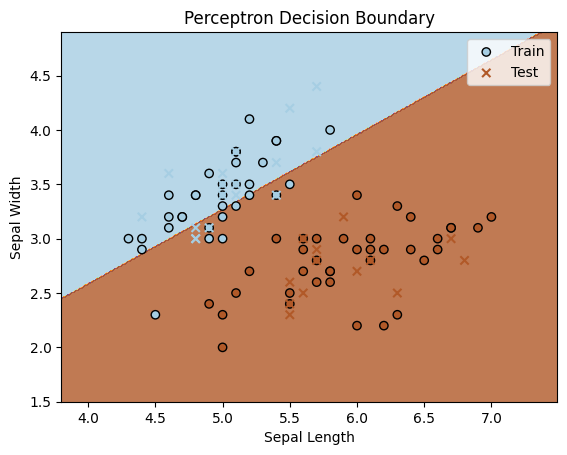

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split

# Step 1: Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Class labels

# Step 2: Filter the dataset to keep only Setosa (label 0) and Versicolor (label 1) classes
setosa_versicolor_indices = np.where((y == 0) | (y == 1))
X_filtered = X[setosa_versicolor_indices]
y_filtered = y[setosa_versicolor_indices]

# Step 3: Select two features: Sepal length (0) and Sepal width (1)
X_filtered = X_filtered[:, [0, 1]]

# Step 4: Train a Perceptron
perceptron = Perceptron()
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.3, random_state=42)
perceptron.fit(X_train, y_train)

# Step 5: Visualize the decision boundary
# Create a mesh grid for plotting the decision boundary
x_min, x_max = X_filtered[:, 0].min() - 0.5, X_filtered[:, 0].max() + 0.5
y_min, y_max = X_filtered[:, 1].min() - 0.5, X_filtered[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# Predict on the grid points
Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker='o', label='Train', edgecolor='k', cmap=plt.cm.Paired)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='x', label='Test', edgecolor='k', cmap=plt.cm.Paired)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Perceptron Decision Boundary')
plt.legend()
plt.show()

#### Explanation of Code:

1.  **Import Libraries**: Necessary libraries like `numpy` for numerical operations, `matplotlib.pyplot` for plotting, `sklearn.datasets` to load Iris, `sklearn.linear_model.Perceptron` for the model, and `sklearn.model_selection.train_test_split` for data splitting are imported.
2.  **Load Iris Dataset**: The `load_iris()` function fetches the dataset. `X` contains features and `y` contains target labels.
3.  **Filter Data**: Since Perceptron is a binary classifier, we filter the dataset to include only classes 0 (Setosa) and 1 (Versicolor).
4.  **Select Features**: We select the first two features (Sepal Length and Sepal Width) for visualization purposes.
5.  **Train Perceptron**: The data is split into training and testing sets. A `Perceptron` model is initialized and trained using the training data.
6.  **Visualize Decision Boundary**: A mesh grid is created over the feature space. The trained Perceptron predicts the class for each point in the grid. This prediction `Z` is then used to plot the decision boundary using `plt.contourf`. The training and testing data points are also plotted to show how the Perceptron separates them.

### Perceptron on Moon Dataset

Here, we apply the Perceptron model to a non-linearly separable dataset known as the 'Moon' dataset. This will illustrate the limitations of a simple Perceptron on complex data distributions.

<ipython-input-2-9d7a482debef>:28: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='x', label='Test', edgecolor='k', cmap=plt.cm.Paired)


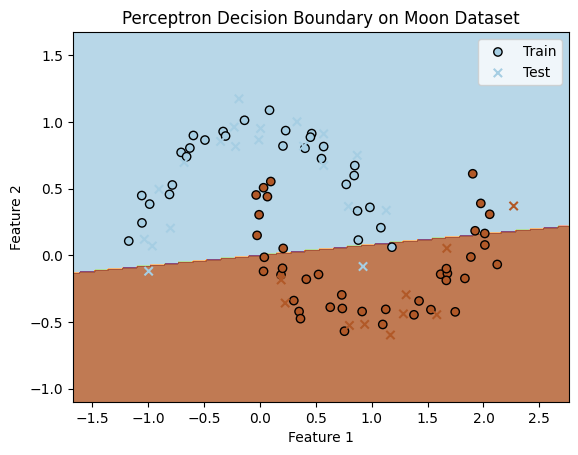

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split

# Step 1: Generate the Moon dataset
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)

# Step 2: Train a Perceptron
perceptron = Perceptron()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
perceptron.fit(X_train, y_train)

# Step 3: Visualize the decision boundary
# Create a mesh grid for plotting the decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# Predict on the grid points
Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker='o', label='Train', edgecolor='k', cmap=plt.cm.Paired)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='x', label='Test', edgecolor='k', cmap=plt.cm.Paired)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary on Moon Dataset')
plt.legend()
plt.show()

#### Explanation of Code:

1.  **Generate Moon Dataset**: The `make_moons` function from `sklearn.datasets` is used to create a synthetic 2D dataset that is not linearly separable. `X` contains features, and `y` contains target labels.
2.  **Train Perceptron**: Similar to Task 1, the dataset is split, and a `Perceptron` model is trained on the training data.
3.  **Visualize Decision Boundary**: The process for visualizing the decision boundary is identical to Task 1, creating a mesh grid and plotting the Perceptron's classification. Observing this plot will highlight that a single Perceptron struggles to correctly classify the moon-shaped data due to its linear nature.

### Multi-Layer Perceptron (MLP) on Breast Cancer Dataset

This section demonstrates a more advanced neural network, the Multi-Layer Perceptron (MLP), for a binary classification task using the Breast Cancer Wisconsin dataset. Unlike the simple Perceptron, MLP can learn non-linear decision boundaries, making it suitable for more complex classification problems. We will evaluate its performance using accuracy and a confusion matrix.

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Step 1: Load the Breast Cancer Wisconsin dataset
data = load_breast_cancer()
X = data.data      # Features
y = data.target    # Labels

# Step 2: Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initialize and configure the MLPClassifier
# Experiment with different hidden layer sizes, e.g., (10,) or (10, 5)
mlp = MLPClassifier(hidden_layer_sizes=(10, 5), activation='relu', solver='adam', max_iter=1000, random_state=42)

# Step 4: Train the MLP on the training data
mlp.fit(X_train, y_train)

# Step 5: Evaluate the model's performance on the test data
y_pred = mlp.predict(X_test)

#### Explanation of Code (Part 1):

1.  **Import Libraries**: Essential libraries include `numpy`, `sklearn.datasets.load_breast_cancer`, `sklearn.model_selection.train_test_split`, `sklearn.neural_network.MLPClassifier`, and `sklearn.metrics` for evaluation.
2.  **Load Breast Cancer Dataset**: The `load_breast_cancer()` function provides the dataset. `X` contains the features, and `y` contains the binary labels (malignant/benign).
3.  **Split Data**: The dataset is split into training (80%) and testing (20%) sets to evaluate the model's generalization performance.
4.  **Initialize MLPClassifier**: An `MLPClassifier` is initialized. Key parameters are:
    *   `hidden_layer_sizes=(10, 5)`: Defines two hidden layers with 10 and 5 neurons, respectively. This allows the MLP to learn complex non-linear relationships.
    *   `activation='relu'`: Uses the Rectified Linear Unit activation function, a common choice for hidden layers.
    *   `solver='adam'`: Specifies the Adam optimizer for weight optimization.
    *   `max_iter=1000`: Sets the maximum number of iterations for the solver.
    *   `random_state=42`: Ensures reproducibility of the results.
5.  **Train MLP**: The `mlp.fit()` method trains the model using the training features and labels.
6.  **Make Predictions**: After training, `mlp.predict()` is used to make predictions on the unseen test data (`X_test`).

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

Accuracy: 0.96
Confusion Matrix:
[[38  5]
 [ 0 71]]


#### Explanation of Code (Part 2):

1.  **Calculate Accuracy**: `accuracy_score(y_test, y_pred)` compares the true labels (`y_test`) with the model's predictions (`y_pred`) to calculate the overall classification accuracy. The result is printed formatted to two decimal places.
2.  **Display Confusion Matrix**: `confusion_matrix(y_test, y_pred)` generates a confusion matrix, which is a table used to describe the performance of a classification model on a set of test data for which the true values are known. It shows the counts of true positives, true negatives, false positives, and false negatives.

## Conclusion

This notebook illustrated the application of Perceptron and Multi-Layer Perceptron (MLP) models on different datasets. While Perceptrons are effective for linearly separable data, MLPs, with their ability to learn non-linear decision boundaries through hidden layers, are more suited for complex, non-linearly separable problems like the Breast Cancer dataset. The visualizations and evaluation metrics provide insight into the strengths and limitations of these fundamental neural network architectures.